# Phase 2 — Profiling the TLC trip data

Understand the data before asking it research questions. Seven items, each of
which has to end in a number we can quote. Findings are written up in
`research/profile_findings.md`.

Prerequisites:

```bash
python src/tlc.py trips --service yellow --start 2019-01 --end 2026-07
python src/weather.py --end 2026-07-31
python src/events.py
python src/panel.py --service yellow --start 2019-01 --end 2026-07
```

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sys.path.insert(0, str(Path.cwd().parent / "src"))

import events
import panel as pnl
import speed
from constants import MIDTOWN_EXTENDED_ZONES

pd.set_option("display.width", 160)
sns.set_theme(style="whitegrid")

panel = pnl.load_panel()
pairs = pnl.load_zone_pairs()

print(f"panel: {len(panel):,} rows, {panel.date.min():%Y-%m-%d} to {panel.date.max():%Y-%m-%d}")
print("areas:", sorted(panel.area.unique()))

panel: 387,635 rows, 2019-01-01 to 2026-07-31
areas: ['cbd', 'cbd_boundary', 'midtown_core', 'midtown_ext', 'un_core', 'uptown']


In [ ]:
pnl

<module 'panel' from '/Users/thatcher/dev/analysis/projects/nyc_average_speed/src/panel.py'>

## 1. Volume by month, 2019 → 2026

Quantify the yellow taxi decline and the COVID hole. This decides whether
2020–21 is usable at all.

## 0. Data quality — before anything else

Scan for days where the source file is missing most of its trips. Volume alone
cannot tell a blizzard from an outage, so every flagged day gets checked against
the weather archive.

In [2]:
flagged = pnl.detect_outages(panel)
print(f"{len(flagged)} days below 50% of their local median\n")

import weather
w = weather.load()
w["date"] = pd.to_datetime(w["date"])
wx = w.groupby("date").agg(snow_cm=("snow_cm", "sum"), precip=("precip_mm", "sum"),
                           tmin=("temp_c", "min"), snow_depth=("snow_depth_m", "max"))

check = flagged.join(wx).assign(dow=lambda d: d.index.day_name().str[:3])
check.round(2)

17 days below 50% of their local median



,trips,local_median,ratio,snow_cm,precip,tmin,snow_depth,dow
2020-11-26,6590,16783.0,0.39,0.00,12.7,9.4,0.00,Thu
2020-12-17,7795,16276.0,0.48,12.25,17.9,-4.4,0.20,Thu
2020-12-25,5140,13965.0,0.37,0.00,35.8,-1.0,0.02,Fri
2021-02-01,1603,15721.0,0.10,27.02,38.6,-4.2,0.27,Mon
2021-02-02,7946,16153.0,0.49,2.80,4.1,-1.8,0.28,Tue
2021-02-07,8304,16758.0,0.50,5.32,7.7,-4.6,0.27,Sun
2022-01-29,16026,33159.0,0.48,13.09,18.6,-12.5,0.15,Sat
2022-09-18,1028,39974.0,0.03,0.00,0.0,17.3,0.00,Sun
2022-12-25,17506,35508.0,0.49,0.00,0.0,-10.0,0.00,Sun
2023-09-21,15346,40532.0,0.38,0.00,0.0,11.6,0.00,Thu


A day that is dry, mild, not a holiday, and still down at 2–4% of normal across
*every* zone at once is a source outage. Those are recorded in
`constants.TLC_OUTAGE_DATES` and removed by `panel.drop_outages()`.

In [3]:
from constants import KNOWN_LOW_TRAFFIC_DATES, TLC_OUTAGE_DATES

print("source outages (excluded):")
for d, why in sorted(TLC_OUTAGE_DATES.items()):
    print(f"  {d}  {why}")
print("\nreal low-traffic days (kept):")
for d, why in sorted(KNOWN_LOW_TRAFFIC_DATES.items()):
    print(f"  {d}  {why}")

before = len(panel)
panel = pnl.drop_outages(panel)
print(f"\npanel: {before:,} -> {len(panel):,} rows")

source outages (excluded):
  2022-09-18  2.6% of normal citywide; dry, 17C, no holiday
  2023-09-21  37.9% of normal; dry
  2023-09-22  1.9% of normal; dry
  2023-09-23  3.2% of normal
  2023-09-24  2.6% of normal

real low-traffic days (kept):
  2020-11-26  Thanksgiving
  2020-12-17  12cm snow
  2020-12-25  Christmas
  2021-02-01  blizzard, 27cm
  2021-02-02  blizzard aftermath
  2021-02-07  snow
  2022-01-29  blizzard, 13cm
  2022-12-25  Christmas
  2023-12-25  Christmas
  2026-01-25  blizzard, 19cm
  2026-01-26  blizzard aftermath
  2026-02-23  snow, 15cm

panel: 387,635 -> 387,107 rows


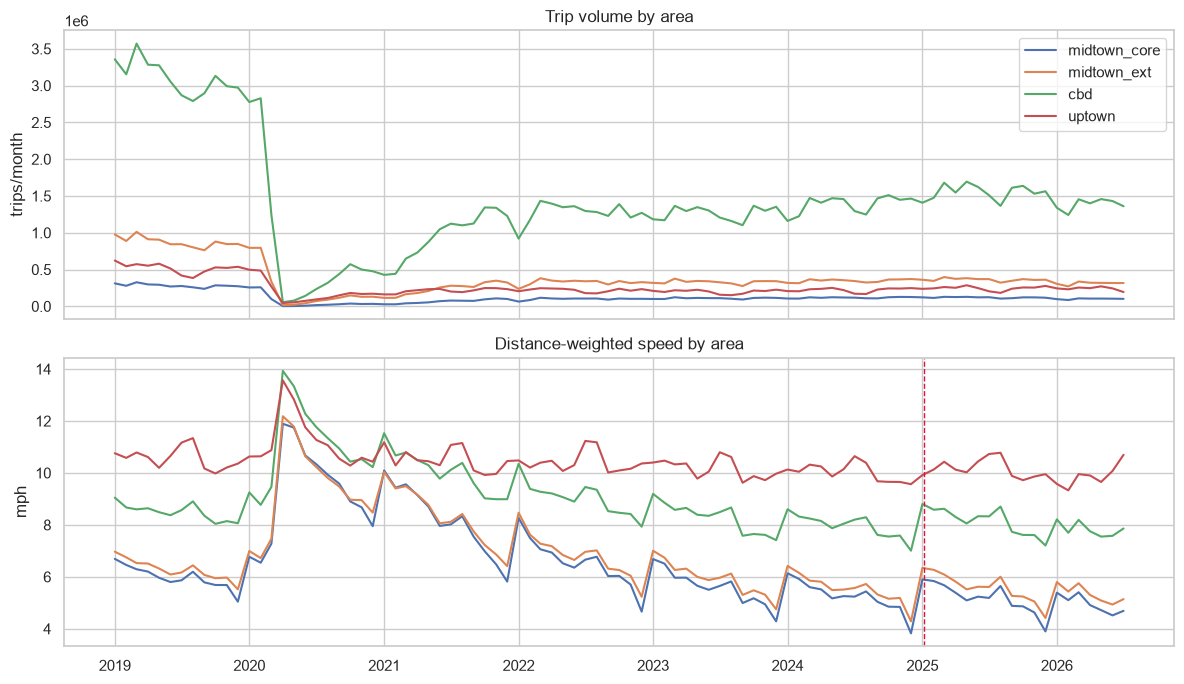

In [4]:
monthly = (
    panel.assign(ym=panel.date.values.astype("datetime64[M]"))
    .groupby(["ym", "area"], as_index=False)
    .agg(trips=("trips", "sum"), miles=("miles", "sum"), minutes=("minutes", "sum"))
)
monthly["mph"] = monthly.miles / (monthly.minutes / 60)

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
for area in ["midtown_core", "midtown_ext", "cbd", "uptown"]:
    sub = monthly[monthly.area == area]
    axes[0].plot(sub.ym, sub.trips, label=area)
    axes[1].plot(sub.ym, sub.mph, label=area)

axes[0].set(ylabel="trips/month", title="Trip volume by area")
axes[0].legend()
axes[1].set(ylabel="mph", title="Distance-weighted speed by area")
axes[1].axvline(pd.Timestamp("2025-01-05"), color="crimson", ls="--", lw=1)
plt.tight_layout()
plt.show()

In [5]:
core_m = monthly[monthly.area == "midtown_core"].set_index("ym")

def yr(y):
    s = core_m[core_m.index.year == y]
    return pd.Series({"trips": s.trips.sum(), "mph": s.miles.sum() / (s.minutes.sum() / 60)})

summary = pd.DataFrame({y: yr(y) for y in range(2019, 2027)}).T
summary["trips"] = summary.trips.astype(int)
summary["vs_2019"] = (summary.trips / summary.loc[2019, "trips"]).round(3)
summary.round(2)

,trips,mph,vs_2019
2019,3386339,5.96,1.00
2020,794417,7.20,0.24
2021,793605,7.51,0.23
2022,1190988,6.38,0.35
2023,1308664,5.51,0.39
2024,1402552,5.14,0.41
2025,1438834,5.13,0.42
2026,705627,4.94,0.21


**Decision point:** if 2020–21 volume or speed is far outside the rest, those
years come out of the seasonal baseline (RQ1) but can stay in RQ3's trend fit as
long as the fit handles them explicitly.

## 2. Distributions and meter errors

Where do implausible trips come from, and how many are there? This reads one
month raw — before filtering — so we can see what the bounds remove.

In [6]:
raw = speed.add_speed(speed.load_month("yellow", 2024, 9))
raw = speed.tag_geography(raw)
print(f"{len(raw):,} raw trips in 2024-09")

core_raw = raw[raw.midtown_core]
print(f"{len(core_raw):,} midtown core")

core_raw[["miles", "minutes", "mph"]].describe(
    percentiles=[0.001, 0.01, 0.25, 0.5, 0.75, 0.99, 0.999]
).round(2)

3,633,030 raw trips in 2024-09
117,869 midtown core


/Users/thatcher/dev/analysis/projects/nyc_average_speed/venv/lib/python3.14/site-packages/pandas/core/nanops.py:1028: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


,miles,minutes,mph
count,117869.00,117869.00,117862.00
mean,2.64,10.65,inf
std,432.77,28.66,NaN
min,0.00,0.00,0.00
0.1%,0.00,0.07,0.00
1%,0.00,0.12,0.00
25%,0.53,5.65,3.59
50%,0.80,8.83,5.22
75%,1.09,13.07,7.22
99%,2.11,33.22,15.02


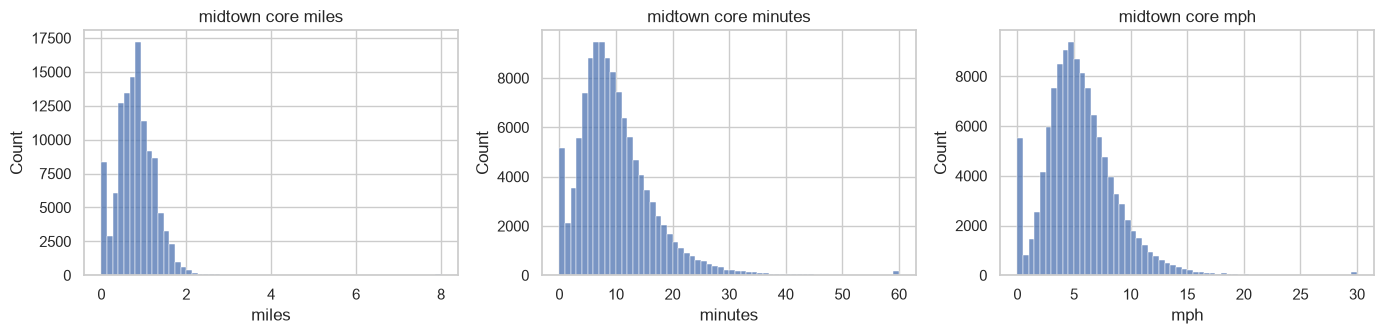

zero distance:       4.31%
zero/neg duration:   0.01%
over 40 mph:         0.10%
under 1 mph:         5.38%


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))
for ax, col, rng in zip(axes, ["miles", "minutes", "mph"], [(0, 8), (0, 60), (0, 30)]):
    sns.histplot(core_raw[col].clip(*rng), bins=60, ax=ax)
    ax.set(title=f"midtown core {col}", xlabel=col)
plt.tight_layout()
plt.show()

# Pathologies the bounds are meant to catch.
print("zero distance:      ", f"{(core_raw.miles <= 0).mean():.2%}")
print("zero/neg duration:  ", f"{(core_raw.minutes <= 0).mean():.2%}")
print("over 40 mph:        ", f"{(core_raw.mph > 40).mean():.2%}")
print("under 1 mph:        ", f"{(core_raw.mph < 1).mean():.2%}")

## 3. Filter sensitivity

The headline number is only as solid as the bounds in `constants.py`. Move each
one and see how far the answer travels.

In [8]:
speed.drop_report(core_raw).assign(share=lambda d: d.share.map("{:.2%}".format))

,bound,range,dropped,share
0,miles,0.2-10.0,9369,7.95%
1,minutes,1.0-90.0,5246,4.45%
2,mph,1.0-40.0,6463,5.48%


In [9]:
def headline(frame, bounds):
    kept = speed.filter_plausible(frame, bounds)
    return pd.Series({
        "trips": len(kept),
        "kept": len(kept) / len(frame),
        "weighted_mph": kept.miles.sum() / (kept.minutes.sum() / 60),
        "mean_mph": kept.mph.mean(),
        "median_mph": kept.mph.median(),
    })

variants = {"default": speed.DEFAULT_BOUNDS}
for name, key, value in [
    ("mph cap 25", "mph", (1.0, 25.0)),
    ("mph cap 60", "mph", (1.0, 60.0)),
    ("mph floor 0.5", "mph", (0.5, 40.0)),
    ("miles max 5", "miles", (0.2, 5.0)),
    ("miles max 20", "miles", (0.2, 20.0)),
    ("miles min 0.5", "miles", (0.5, 10.0)),
    ("minutes max 45", "minutes", (1.0, 45.0)),
    ("minutes min 2", "minutes", (2.0, 90.0)),
]:
    variants[name] = {**speed.DEFAULT_BOUNDS, key: value}

sens = pd.DataFrame({name: headline(core_raw, b) for name, b in variants.items()}).T
sens["vs_default"] = (sens.weighted_mph - sens.loc["default", "weighted_mph"]).round(3)
sens.round(3)

,trips,kept,weighted_mph,mean_mph,median_mph,vs_default
default,108003.0,0.916,5.038,5.927,5.450,0.000
mph cap 25,107984.0,0.916,5.037,5.923,5.450,-0.001
mph cap 60,108012.0,0.916,5.039,5.931,5.451,0.001
mph floor 0.5,108293.0,0.919,5.010,5.914,5.441,-0.027
miles max 5,107905.0,0.915,5.024,5.924,5.448,-0.014
miles max 20,108051.0,0.917,5.065,5.933,5.452,0.027
miles min 0.5,92581.0,0.785,5.155,6.083,5.602,0.117
minutes max 45,107774.0,0.914,5.053,5.932,5.455,0.016
minutes min 2,107128.0,0.909,5.029,5.873,5.425,-0.009


**Read this as:** any bound whose `vs_default` is more than a few hundredths
of a mph is load-bearing and belongs in `research/limitations.md` with its
magnitude attached.

## 4. Sample size

Sets the finest time slice the rest of the analysis is allowed to cut.

In [10]:
daily = (
    panel.groupby(["area", "date"], as_index=False)
    .agg(trips=("trips", "sum"))
)

for area in ["midtown_core", "midtown_ext"]:
    d = daily[daily.area == area].set_index("date").trips
    print(f"{area:14s} per day: median {d.median():>7,.0f}  p05 {d.quantile(.05):>7,.0f}")

hourly = panel[panel.area == "midtown_core"].groupby("hour").trips.median()
print("\nmidtown_core median trips per hour-of-day:")
print(hourly.round(0).to_string())

midtown_core   per day: median   3,552  p05     468
midtown_ext    per day: median  11,030  p05   2,271

midtown_core median trips per hour-of-day:
hour
0      56.0
1      26.0
2      13.0
3       8.0
4       7.0
5      26.0
6      63.0
7      97.0
8     138.0
9     156.0
10    170.0
11    196.0
12    214.0
13    225.0
14    225.0
15    231.0
16    248.0
17    272.0
18    286.0
19    240.0
20    180.0
21    170.0
22    153.0
23    105.0


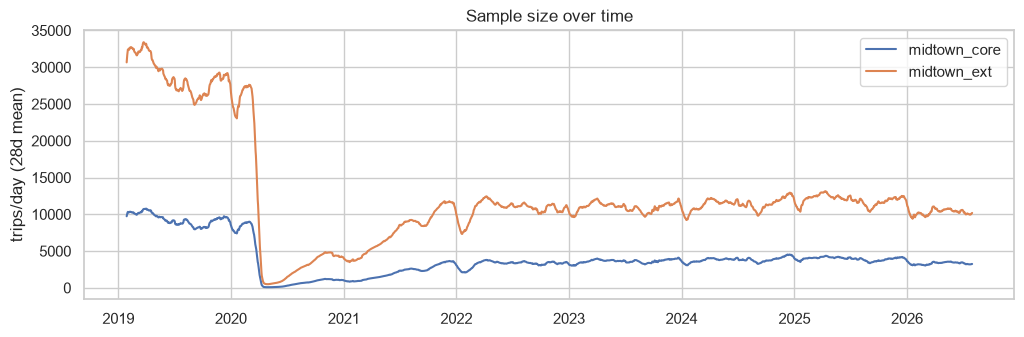

In [11]:
fig, ax = plt.subplots(figsize=(12, 3.5))
for area in ["midtown_core", "midtown_ext"]:
    d = daily[daily.area == area].set_index("date").trips
    ax.plot(d.index, d.rolling(28).mean(), label=area)
ax.set(ylabel="trips/day (28d mean)", title="Sample size over time")
ax.legend()
plt.show()

## 5. Composition drift — the one that can invalidate everything

If the mix of midtown origin–destination pairs shifts, the average speed moves
with no change in congestion. `decompose_composition` splits the observed series
into a fixed-mix component (speed only) and the residual the mix explains.

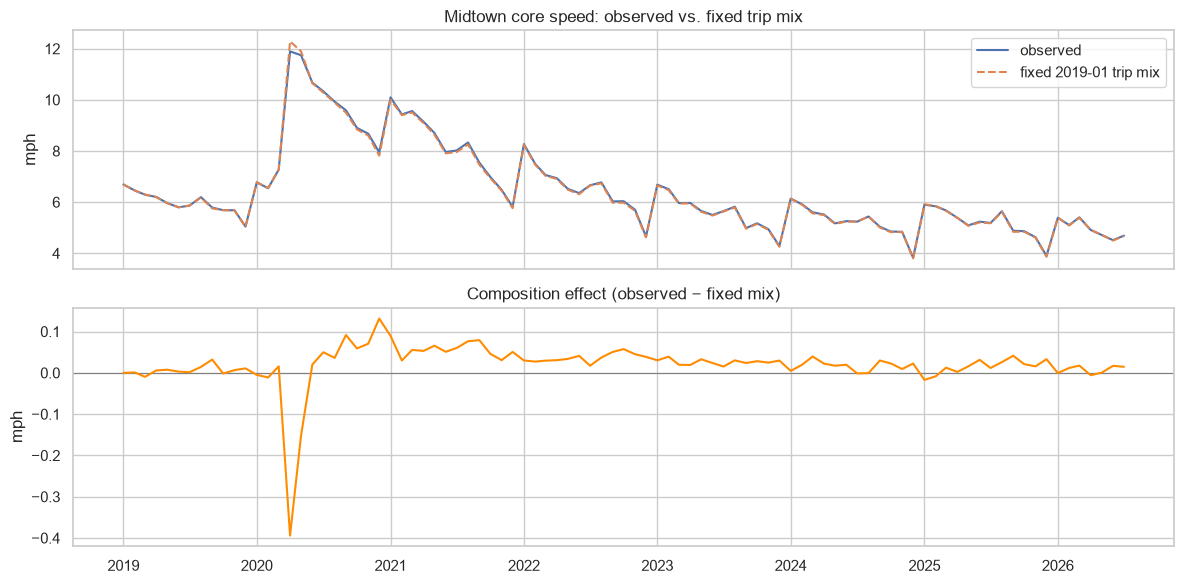

,observed_mph,fixed_mix_mph,composition_mph,pair_coverage
date,,,,
2024-08-01,5.438,5.439,-0.001,1.0
2024-09-01,5.038,5.008,0.030,1.0
2024-10-01,4.850,4.828,0.023,1.0
2024-11-01,4.840,4.831,0.009,1.0
2024-12-01,3.823,3.801,0.022,1.0
2025-01-01,5.900,5.917,-0.017,1.0
2025-02-01,5.837,5.845,-0.008,1.0
2025-03-01,5.675,5.662,0.012,1.0
2025-04-01,5.387,5.385,0.002,1.0


In [12]:
decomp = pnl.decompose_composition(pairs, area="midtown_core", baseline=(2019, 1))

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
axes[0].plot(decomp.date, decomp.observed_mph, label="observed")
axes[0].plot(decomp.date, decomp.fixed_mix_mph, label="fixed 2019-01 trip mix", ls="--")
axes[0].set(ylabel="mph", title="Midtown core speed: observed vs. fixed trip mix")
axes[0].legend()

axes[1].axhline(0, color="grey", lw=0.8)
axes[1].plot(decomp.date, decomp.composition_mph, color="darkorange")
axes[1].set(ylabel="mph", title="Composition effect (observed − fixed mix)")
plt.tight_layout()
plt.show()

decomp.set_index("date")[["observed_mph", "fixed_mix_mph", "composition_mph", "pair_coverage"]].round(3).tail(24)

In [13]:
print("composition effect, mph:")
print(f"  mean |effect|:  {decomp.composition_mph.abs().mean():.3f}")
print(f"  max  |effect|:  {decomp.composition_mph.abs().max():.3f}")
print(f"  2026 vs 2019:   {decomp[decomp.year == 2026].composition_mph.mean():.3f}")
print(f"\nobserved 2019 → 2026: "
      f"{decomp[decomp.year == 2019].observed_mph.mean():.2f} → "
      f"{decomp[decomp.year == 2026].observed_mph.mean():.2f} mph")
print(f"fixed-mix 2019 → 2026: "
      f"{decomp[decomp.year == 2019].fixed_mix_mph.mean():.2f} → "
      f"{decomp[decomp.year == 2026].fixed_mix_mph.mean():.2f} mph")

composition effect, mph:
  mean |effect|:  0.034
  max  |effect|:  0.394
  2026 vs 2019:   0.008

observed 2019 → 2026: 5.97 → 4.96 mph
fixed-mix 2019 → 2026: 5.97 → 4.95 mph


**Verdict to record:** if the composition effect is small relative to the
change we care about, report it as a checked-and-dismissed limitation. If it is
comparable, every headline number in Phases 3+ has to be a fixed-mix number.

## 6. Which aggregate do we lead with?

Mean of trip speeds over-weights short crosstown hops that dominate by count but
not by distance. Distance-weighted is the candidate.

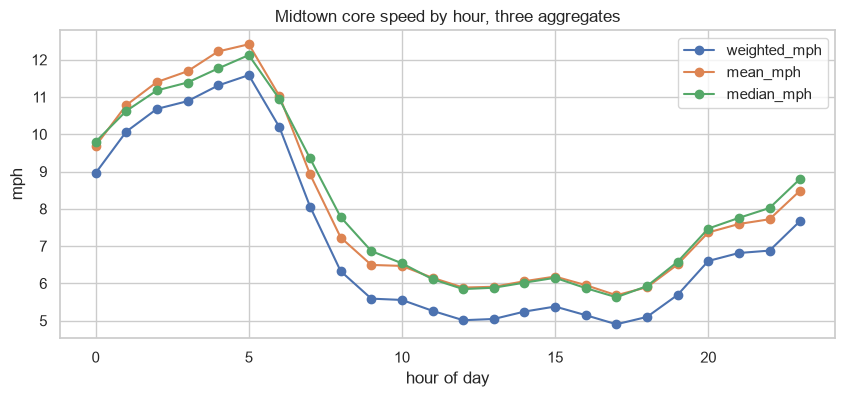

,trips,weighted_mph,mean_mph,median_mph
hour,,,,
0,199017,8.96,9.69,9.80
1,104759,10.07,10.78,10.63
2,57072,10.68,11.40,11.18
3,36208,10.89,11.69,11.39
4,30693,11.31,12.22,11.77
5,90181,11.59,12.41,12.12
6,231404,10.19,11.03,10.94
7,374407,8.06,8.93,9.35
8,481633,6.33,7.23,7.78


In [14]:
core = panel[panel.area == "midtown_core"]
by_hour = core.groupby("hour").agg(
    trips=("trips", "sum"), miles=("miles", "sum"), minutes=("minutes", "sum"),
)
by_hour["weighted_mph"] = by_hour.miles / (by_hour.minutes / 60)
by_hour["mean_mph"] = (
    core.assign(w=core.mean_mph * core.trips).groupby("hour").w.sum() / by_hour.trips
)
by_hour["median_mph"] = core.groupby("hour").p50_mph.median()

fig, ax = plt.subplots(figsize=(10, 4))
by_hour[["weighted_mph", "mean_mph", "median_mph"]].plot(ax=ax, marker="o")
ax.set(xlabel="hour of day", ylabel="mph", title="Midtown core speed by hour, three aggregates")
plt.show()

by_hour[["trips", "weighted_mph", "mean_mph", "median_mph"]].round(2)

## 7. Do the weather and event joins behave?

Wet hours should be visibly slower than dry, and permitted-closure days slower
than clean days. If not, the join is wrong — check before trusting either as a
control in Phase 3.

In [15]:
core = panel[panel.area == "midtown_core"]

def wmph(g):
    return g.miles.sum() / (g.minutes.sum() / 60)

print("midtown core, distance-weighted mph:")
for label, mask in [
    ("dry",            ~core.is_wet.fillna(False)),
    ("wet",             core.is_wet.fillna(False)),
    ("heavy precip",    core.is_heavy_precip.fillna(False)),
    ("snowing",         core.is_snowing.fillna(False)),
    ("snow on ground",  core.has_snow_cover.fillna(False)),
]:
    sub = core[mask]
    print(f"  {label:16s} {wmph(sub):5.2f}   ({sub.trips.sum():>10,.0f} trips)")

midtown core, distance-weighted mph:
  dry               5.86   ( 9,073,943 trips)
  wet               5.56   ( 1,947,083 trips)
  heavy precip      5.49   (   168,618 trips)
  snowing           6.03   (   158,032 trips)
  snow on ground    5.86   ( 1,537,171 trips)


In [16]:
# Restrict to business hours so the comparison is not a time-of-day artefact.
busy = core[core.hour.between(8, 19)]
print("business hours (08-19) only:")
print(f"  dry {wmph(busy[~busy.is_wet.fillna(False)]):.2f} mph"
      f"   wet {wmph(busy[busy.is_wet.fillna(False)]):.2f} mph")

business hours (08-19) only:
  dry 5.34 mph   wet 5.07 mph


In [17]:
ev = events.load()
closures = events.daily_midtown_closures(ev)
closures["date"] = pd.to_datetime(closures.date)

daily_core = (
    core.groupby("date", as_index=False)
    .agg(miles=("miles", "sum"), minutes=("minutes", "sum"), trips=("trips", "sum"))
    .merge(closures, on="date", how="left")
)
daily_core["mph"] = daily_core.miles / (daily_core.minutes / 60)
daily_core[["road_events", "full_closures"]] = daily_core[["road_events", "full_closures"]].fillna(0)
daily_core["dow"] = daily_core.date.dt.dayofweek

# Weekdays only - closures cluster on weekends, and so does light traffic.
wd = daily_core[daily_core.dow < 5]
bucket = pd.cut(wd.road_events, [-1, 0, 2, 5, 100], labels=["0", "1-2", "3-5", "6+"])
print("midtown weekday speed by road-affecting permits that day:")
print(wd.groupby(bucket, observed=True).agg(days=("mph", "size"), mph=("mph", "mean")).round(2))

midtown weekday speed by road-affecting permits that day:
             days   mph
road_events            
0             321  7.67
1-2           819  6.76
3-5           643  5.76
6+            194  5.31


---

## Writing up

Record every number above in `research/profile_findings.md`, and move anything
load-bearing into `research/limitations.md` with its magnitude.

---

## Preview: UNGA week ranking (feeds RQ2)

Not the full RQ2 analysis — just enough to confirm the pipeline surfaces the
effect, and to check what the outage exclusion costs.

In [18]:
from constants import UNGA_GENERAL_DEBATE, unga_week

core = panel[panel.area == "midtown_core"]
dc = core.groupby("date", as_index=False).agg(miles=("miles", "sum"), minutes=("minutes", "sum"))
dc = dc[dc.date.dt.dayofweek < 5]
dc["iy"] = dc.date.dt.isocalendar().year
dc["iw"] = dc.date.dt.isocalendar().week

wk = dc.groupby(["iy", "iw"]).apply(
    lambda g: pd.Series({"mph": g.miles.sum() / (g.minutes.sum() / 60), "days": len(g)}),
    include_groups=False,
)

rows = []
for y in sorted(UNGA_GENERAL_DEBATE):
    iso = pd.Timestamp(unga_week(y)[0]).isocalendar()
    if (iso.year, iso.week) not in wk.index:
        continue
    elig = wk.loc[y][lambda d: d.days >= 4]
    if iso.week not in elig.index:
        rows.append({"year": y, "week": iso.week, "mph": np.nan, "rank": "excluded",
                     "of": len(elig), "median": elig.mph.median()})
        continue
    rows.append({"year": y, "week": iso.week, "mph": wk.loc[(iso.year, iso.week)].mph,
                 "rank": int(elig.mph.rank().loc[iso.week]), "of": len(elig),
                 "median": elig.mph.median()})

unga = pd.DataFrame(rows).set_index("year")
unga["gap"] = (unga.mph - unga["median"]).round(2)
unga.round(2)

,week,mph,rank,of,median,gap
year,,,,,,
2019,39,4.63,1,52,5.77,-1.14
2020,39,9.51,28,53,9.50,0.01
2021,38,6.40,5,52,8.08,-1.68
2022,38,4.77,5,52,6.43,-1.65
2023,38,NaN,excluded,51,5.47,NaN
2024,39,4.22,5,52,5.11,-0.89
2025,39,3.78,3,52,5.01,-1.22


2020 is the one to look at. The General Debate ran on pre-recorded video with
almost no delegations present — UNGA on the calendar, no motorcades. If the
slowdown in ordinary years is real, 2020 should sit at the median. It does.

## Preview: congestion pricing (feeds RQ3)

Raw before/after with a control group. No weather or mix adjustment — this is a
direction check, not an estimate.

In [19]:
jj = panel[panel.date.dt.month <= 7]          # same months, so partial 2026 compares
rows = {}
for area in ["midtown_core", "cbd", "uptown", "cbd_boundary"]:
    a = jj[jj.area == area]
    rows[area] = a.groupby(a.date.dt.year).apply(
        lambda g: g.miles.sum() / (g.minutes.sum() / 60), include_groups=False
    )

did = pd.DataFrame(rows).round(3)
did.loc["Δ 2024→2025"] = (did.loc[2025] - did.loc[2024]).round(3)
did.loc["Δ 2025→2026"] = (did.loc[2026] - did.loc[2025]).round(3)
print(did.to_string())
print(f"\nDiD (cbd - uptown) 2024→2025: {did.loc['Δ 2024→2025','cbd'] - did.loc['Δ 2024→2025','uptown']:+.3f} mph")
print(f"DiD (cbd - uptown) 2025→2026: {did.loc['Δ 2025→2026','cbd'] - did.loc['Δ 2025→2026','uptown']:+.3f} mph")

             midtown_core     cbd  uptown  cbd_boundary
date                                                   
2019                6.176   8.622  10.655         7.978
2020                6.879   9.247  10.930         8.370
2021                8.663  10.338  10.626         8.690
2022                6.917   9.303  10.415         8.138
2023                5.946   8.622  10.280         7.814
2024                5.512   8.180  10.177         7.532
2025                5.452   8.412  10.245         7.491
2026                4.937   7.823   9.851         7.052
Δ 2024→2025        -0.060   0.232   0.068        -0.041
Δ 2025→2026        -0.515  -0.589  -0.394        -0.439

DiD (cbd - uptown) 2024→2025: +0.164 mph
DiD (cbd - uptown) 2025→2026: -0.195 mph
